# Hazy-DIOR — Exploratory Data Analysis

End-to-end EDA for the **Hazy-DIOR** remote-sensing object-detection dataset used in the NIRNet paper *(Noise Incentive Robust Network in Remote Sensing Object Detection Under Cloud Corruption)*.

This notebook is **self-contained**: it does not import MMRotate. It extracts the split-zip archive, parses the XML annotations the same way [nirnet-main/mmrotate/datasets/dior.py](nirnet-main/mmrotate/datasets/dior.py) does, and reports:

1. Archive extraction (handles WinRAR-style split zips)
2. Filesystem structure
3. Train / val / test split sizes
4. XML annotation parsing into pandas DataFrames
5. Class distribution
6. Bounding-box statistics (size, aspect, angle, count per image, spatial bias)
7. Image statistics
8. Sample visualizations with **oriented** bounding boxes
9. Haze-specific image characteristics (channel stats, Dark Channel Prior, atmospheric light, colorfulness, clean-vs-hazy comparison)
10. Output artifacts saved to `eda_outputs/`


## 1 — Setup

Imports and constants. If you are on a fresh environment, uncomment the `pip install` cell below.

In [21]:
!pip install numpy pandas matplotlib seaborn opencv-python pillow tqdm pyarrow

In [22]:
!python -m pip install --upgrade pip

In [23]:
import json
import os
import shutil
import subprocess
import sys
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Paths -----------------------------------------------------------------
ARCHIVE_DIR = Path(r"c:\Users\Ridvan\Desktop\tez\hazyDior")
EXTRACT_DIR = ARCHIVE_DIR / "Hazy-DIOR"
CACHE_DIR   = ARCHIVE_DIR / "eda_cache"
OUT_DIR     = ARCHIVE_DIR / "eda_outputs"
CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# --- DIOR class set + palette (verbatim from mmrotate/datasets/dior.py) ----
CLASSES = (
    'airplane', 'airport', 'baseballfield', 'basketballcourt',
    'bridge', 'chimney', 'expressway-service-area',
    'expressway-toll-station', 'dam', 'golffield',
    'groundtrackfield', 'harbor', 'overpass', 'ship', 'stadium',
    'storagetank', 'tenniscourt', 'trainstation', 'vehicle',
    'windmill',
)
PALETTE = [
    (220, 20, 60), (119, 11, 32), (0, 0, 142), (0, 0, 230),
    (106, 0, 228), (0, 60, 100), (0, 80, 100), (0, 0, 70),
    (0, 0, 192), (250, 170, 30), (100, 170, 30), (220, 220, 0),
    (175, 116, 175), (250, 0, 30), (165, 42, 42), (255, 77, 255),
    (0, 226, 252), (182, 182, 255), (0, 82, 0), (120, 166, 157),
]
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
PALETTE_NORM = [tuple(c / 255 for c in rgb) for rgb in PALETTE]

print(f"ARCHIVE_DIR = {ARCHIVE_DIR}")
print(f"EXTRACT_DIR = {EXTRACT_DIR}")
print(f"{len(CLASSES)} classes")


ARCHIVE_DIR = c:\Users\Ridvan\Desktop\tez\hazyDior
EXTRACT_DIR = c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR
20 classes


## 2 — Archive inventory & extraction

The Hazy-DIOR archive is a multi-part WinRAR-style split zip (`.zip` + `.z01 … z12`). Python's built-in `zipfile` does not reliably handle this format, so we shell out to **7-Zip**, with fallbacks to `unzip` and WinRAR's `Rar.exe`.

If extraction has already been done, this section is a no-op.

In [4]:
# --- 2.1 inventory -------------------------------------------------------
parts = sorted(ARCHIVE_DIR.glob("Hazy-DIOR.z*")) + sorted(ARCHIVE_DIR.glob("Hazy-DIOR.zip"))
inv = pd.DataFrame([
    {"name": p.name, "size_GB": round(p.stat().st_size / 1024**3, 3)}
    for p in parts
]).sort_values("name").reset_index(drop=True)

print(inv.to_string(index=False))
print(f"\nTotal: {inv['size_GB'].sum():.2f} GB across {len(inv)} files")

expected = ["Hazy-DIOR.zip"] + [f"Hazy-DIOR.z{i:02d}" for i in range(1, 13)]
missing = [n for n in expected if n not in inv["name"].tolist()]
if missing:
    print(f"\n[WARN] Missing parts: {missing}")
else:
    print("\n[OK] All 13 expected parts are present.")


         name  size_GB
Hazy-DIOR.z01    2.000
Hazy-DIOR.z02    2.000
Hazy-DIOR.z03    2.000
Hazy-DIOR.z04    2.000
Hazy-DIOR.z05    2.000
Hazy-DIOR.z06    2.000
Hazy-DIOR.z07    2.000
Hazy-DIOR.z08    2.000
Hazy-DIOR.z09    2.000
Hazy-DIOR.z10    2.000
Hazy-DIOR.z11    2.000
Hazy-DIOR.z12    2.000
Hazy-DIOR.zip    1.278
Hazy-DIOR.zip    1.278

Total: 26.56 GB across 14 files

[OK] All 13 expected parts are present.


In [5]:
# --- 2.2 detect an extraction tool --------------------------------------
# Preference: 7-Zip > WinRAR > plain unzip.  Plain `unzip` typically can't
# read WinRAR-style split zips (.zip + .z01.. .z12), so it's a last resort.
def find_extractor() -> tuple[str | None, list[str]]:
    """Return (label, argv-template). Template uses {zip} and {out}."""
    sevenzip_candidates = [
        "7z",
        r"C:\Program Files\7-Zip\7z.exe",
        r"C:\Program Files (x86)\7-Zip\7z.exe",
    ]
    for exe in sevenzip_candidates:
        if shutil.which(exe) or Path(exe).exists():
            return "7-Zip", [exe, "x", "-y", "{zip}", "-o{out}"]
    winrar_candidates = [
        r"C:\Program Files\WinRAR\WinRAR.exe",
        r"C:\Program Files (x86)\WinRAR\WinRAR.exe",
    ]
    for exe in winrar_candidates:
        if Path(exe).exists():
            # `x` extract w/ paths, -y assume yes, -ibck run in background.
            # Trailing backslash on dest is required by WinRAR's CLI.
            return "WinRAR", [exe, "x", "-y", "-ibck", "{zip}", "{out}\\"]
    if shutil.which("unzip"):
        return "unzip", ["unzip", "-o", "{zip}", "-d", "{out}"]
    return None, []

tool, template = find_extractor()
if tool is None:
    print("[ERROR] No extractor found. Install 7-Zip:")
    print("    winget install 7zip.7zip")
else:
    print(f"Using: {tool}")
    print(f"Command: {' '.join(template).format(zip=str(ARCHIVE_DIR/'Hazy-DIOR.zip'), out=str(EXTRACT_DIR))}")


Using: WinRAR
Command: C:\Program Files\WinRAR\WinRAR.exe x -y -ibck c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR.zip c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR\


In [ ]:
# --- 2.3 extract (skipped if JPEGImages/ already exists) ----------------
def already_extracted() -> bool:
    return (EXTRACT_DIR / "JPEGImages").exists() or (EXTRACT_DIR / "Hazy-DIOR" / "JPEGImages").exists()

if already_extracted():
    print(f"[SKIP] {EXTRACT_DIR} already populated.")
elif tool is None:
    print("[SKIP] No extractor available.")
else:
    EXTRACT_DIR.mkdir(exist_ok=True)
    cmd = [a.format(zip=str(ARCHIVE_DIR/'Hazy-DIOR.zip'), out=str(EXTRACT_DIR)) for a in template]
    print(f"Running: {cmd}")
    print("(this can take several minutes on a ~24 GB archive)\n")
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        sys.stdout.write(line)
    proc.wait()
    print(f"\n[exit code = {proc.returncode}]")


Running: ['C:\\Program Files\\WinRAR\\WinRAR.exe', 'x', '-y', '-ibck', 'c:\\Users\\Ridvan\\Desktop\\tez\\hazyDior\\Hazy-DIOR.zip', 'c:\\Users\\Ridvan\\Desktop\\tez\\hazyDior\\Hazy-DIOR\\']
(this can take several minutes on a ~24 GB archive)



## 3 — Filesystem inspection

Walk the extracted tree, count files by extension, and detect which DIOR sub-folders are actually present.

In [49]:
# Resolve DATA_ROOT. Two layouts are supported:
#   (A) Split layout — what the released archive actually uses:
#         DATA_ROOT/{train,val,test}/{gt,haze}/...
#       In particular: test/{gt,haze}/{moderate,thick,thin}/*.jpg
#                  and train/val/{gt,haze}/*.png
#   (B) Legacy flat layout: DATA_ROOT/JPEGImages/*.jpg
def _has_split_layout(d: Path) -> bool:
    return (d / "train" / "haze").exists()

def _has_meta(d: Path) -> bool:
    return (d / "ImageSets" / "Main").exists() or (d / "Annotations").exists()

candidates = [EXTRACT_DIR, EXTRACT_DIR / "Hazy-DIOR", EXTRACT_DIR / "Hazy-DIOR" / "Hazy-DIOR"]
DATA_ROOT = next(
    (c for c in candidates if c.exists() and ((c / "JPEGImages").exists() or _has_split_layout(c))),
    EXTRACT_DIR,
)
SPLIT_LAYOUT = _has_split_layout(DATA_ROOT)

# Annotations and ImageSets typically live one level up from the split-image
# root, so resolve a separate META_ROOT for them.
META_ROOT = next((c for c in candidates if c.exists() and _has_meta(c)), DATA_ROOT)

def show_tree(root: Path, depth: int = 2, prefix: str = "") -> None:
    if depth < 0 or not root.exists():
        return
    children = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for i, child in enumerate(children[:25]):
        is_last = i == len(children[:25]) - 1
        connector = "└── " if is_last else "├── "
        print(prefix + connector + child.name + ("/" if child.is_dir() else ""))
        if child.is_dir() and depth > 0:
            extension = "    " if is_last else "│   "
            show_tree(child, depth - 1, prefix + extension)
    if len(children) > 25:
        print(prefix + f"... ({len(children) - 25} more)")

print(f"DATA_ROOT    = {DATA_ROOT}")
print(f"META_ROOT    = {META_ROOT}")
print(f"SPLIT_LAYOUT = {SPLIT_LAYOUT}\n")
show_tree(META_ROOT, depth=2)


DATA_ROOT    = c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR\Hazy-DIOR
META_ROOT    = c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR
SPLIT_LAYOUT = True

├── Annotations/
│   ├── Horizontal Bounding Boxes/
│   │   ├── 00001.xml
│   │   ├── 00002.xml
│   │   ├── 00003.xml
│   │   ├── 00004.xml
│   │   ├── 00005.xml
│   │   ├── 00006.xml
│   │   ├── 00007.xml
│   │   ├── 00008.xml
│   │   ├── 00009.xml
│   │   ├── 00010.xml
│   │   ├── 00011.xml
│   │   ├── 00012.xml
│   │   ├── 00013.xml
│   │   ├── 00014.xml
│   │   ├── 00015.xml
│   │   ├── 00016.xml
│   │   ├── 00017.xml
│   │   ├── 00018.xml
│   │   ├── 00019.xml
│   │   ├── 00020.xml
│   │   ├── 00021.xml
│   │   ├── 00022.xml
│   │   ├── 00023.xml
│   │   ├── 00024.xml
│   │   └── 00025.xml
│   │   ... (23438 more)
│   └── Oriented Bounding Boxes/
│       ├── 00001.xml
│       ├── 00002.xml
│       ├── 00003.xml
│       ├── 00004.xml
│       ├── 00005.xml
│       ├── 00006.xml
│       ├── 00007.xml
│       ├── 00008.xml
│       ├

In [50]:
# File counts by extension (rooted at META_ROOT so annotation + image trees both show up)
inv_root = META_ROOT if META_ROOT != DATA_ROOT else DATA_ROOT
if inv_root.exists():
    ext_counts = Counter()
    for p in inv_root.rglob("*"):
        if p.is_file():
            ext_counts[p.suffix.lower()] += 1
    print(pd.Series(ext_counts).sort_values(ascending=False).to_string())
else:
    print("inv_root does not exist; skipping.")

# --- Annotations -----------------------------------------------------------
# The Hazy-DIOR release ships annotations split into OBB and HBB sub-folders.
# Prefer OBB (matches mmrotate/datasets/dior.py); fall back to HBB, then flat.
_ann_candidates = [
    META_ROOT / "Annotations" / "Oriented Bounding Boxes",
    META_ROOT / "Annotations" / "Horizontal Bounding Boxes",
    META_ROOT / "Annotations",
]
ANN_DIR = next((d for d in _ann_candidates if d.exists() and any(d.glob("*.xml"))), _ann_candidates[0])

# --- ImageSets -------------------------------------------------------------
SPLITS_DIR = META_ROOT / "ImageSets" / "Main"

# --- Images ---------------------------------------------------------------
# The Hazy-DIOR layout is irregular:
#   - train/{gt,haze}/*.png            (flat ~56k each — pool of hazy variants)
#   - val/{gt,haze}/*.png              (flat ~6k each)
#   - test/{gt,haze}/{moderate,thick,thin}/*.jpg  (3 severity tiers)
# We recursively scan each branch (haze, gt) and map {image_id -> Path} where
# image_id is the file stem. When multiple files share a stem we keep the
# first hit; total file counts are tracked separately so the inventory print
# stays honest.
IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

def _build_id_map(branch: str) -> tuple[dict[str, Path], int]:
    id_map: dict[str, Path] = {}
    total = 0
    if SPLIT_LAYOUT:
        for split_name in ("train", "val", "test"):
            d = DATA_ROOT / split_name / branch
            if not d.exists():
                continue
            for p in d.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                    total += 1
                    id_map.setdefault(p.stem, p)
    else:
        d = DATA_ROOT / ("JPEGImages" if branch == "haze" else branch)
        if d.exists():
            for p in d.iterdir():
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                    total += 1
                    id_map.setdefault(p.stem, p)
    return id_map, total

HAZE_PATHS,  N_HAZE_FILES  = _build_id_map("haze")
CLEAN_PATHS, N_CLEAN_FILES = _build_id_map("gt")
IMG_DIR = DATA_ROOT if SPLIT_LAYOUT else DATA_ROOT / "JPEGImages"

HAS_ANNOTATIONS = ANN_DIR.exists() and any(ANN_DIR.glob("*.xml"))
HAS_IMAGES      = len(HAZE_PATHS) > 0
HAS_IMAGESETS   = SPLITS_DIR.exists() and any(SPLITS_DIR.glob("*.txt"))

print(f"\nANN_DIR    = {ANN_DIR}")
print(f"SPLITS_DIR = {SPLITS_DIR}")
print(f"hazy:  unique IDs = {len(HAZE_PATHS):,}   total files = {N_HAZE_FILES:,}")
print(f"clean: unique IDs = {len(CLEAN_PATHS):,}   total files = {N_CLEAN_FILES:,}")
print(f"\nHAS_ANNOTATIONS = {HAS_ANNOTATIONS}")
print(f"HAS_IMAGES      = {HAS_IMAGES}")
print(f"HAS_IMAGESETS   = {HAS_IMAGESETS}")

if not HAS_ANNOTATIONS:
    print(
        "\n[!] No XML annotations found. Expected one of:\n"
        + "\n".join(f"  - {d}" for d in _ann_candidates)
    )


.png    125136
.xml     46926
.jpg     15642
.txt         3

ANN_DIR    = c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR\Annotations\Oriented Bounding Boxes
SPLITS_DIR = c:\Users\Ridvan\Desktop\tez\hazyDior\Hazy-DIOR\ImageSets\Main
hazy:  unique IDs = 56,310   total files = 70,389
clean: unique IDs = 56,310   total files = 70,389

HAS_ANNOTATIONS = True
HAS_IMAGES      = True
HAS_IMAGESETS   = True


## 4 — Train / val / test splits

DIOR ships three plain-text lists under `ImageSets/Main/` — one image ID per line.

In [51]:
splits: dict[str, list[str]] = {}
if HAS_IMAGESETS:
    for split in ["train", "val", "test", "trainval"]:
        f = SPLITS_DIR / f"{split}.txt"
        if f.exists():
            splits[split] = [ln.strip() for ln in f.read_text().splitlines() if ln.strip()]
    for k, v in splits.items():
        print(f"  {k:8s}: {len(v):>6,} images")
else:
    print("[SKIP] ImageSets/Main/ not found.")


  train   :  5,862 images
  val     :  5,863 images
  test    : 11,738 images


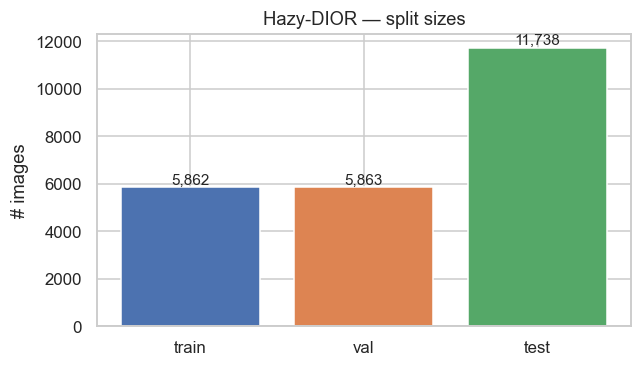

In [52]:
# Bar chart of split sizes
if splits:
    keep = {k: v for k, v in splits.items() if k != "trainval"}
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(keep.keys(), [len(v) for v in keep.values()], color=["#4C72B0", "#DD8452", "#55A868"])
    for x, y in zip(keep.keys(), [len(v) for v in keep.values()]):
        ax.text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title("Hazy-DIOR — split sizes")
    ax.set_ylabel("# images")
    plt.tight_layout()
    plt.show()


In [53]:
# Cross-check: every listed image ID has a matching hazy image and .xml
def check_split(ids: list[str]) -> dict:
    missing_img = sum(1 for i in ids if i not in HAZE_PATHS)
    missing_ann = sum(1 for i in ids if not (ANN_DIR / f"{i}.xml").exists())
    return {"n": len(ids), "missing_img": missing_img, "missing_ann": missing_ann}

if splits and HAS_IMAGES:
    rows = {k: check_split(v) for k, v in splits.items() if k != "trainval"}
    print(pd.DataFrame(rows).T.to_string())


           n  missing_img  missing_ann
train   5862            0            0
val     5863            0            0
test   11738            0            0


## 5 — Annotation parsing

Mirrors the parsing in [nirnet-main/mmrotate/datasets/dior.py:62-171](nirnet-main/mmrotate/datasets/dior.py#L62-L171):

* `<size>` → image w/h
* For each `<object>`: `<name>` lower-cased, oriented box via `<robndbox>` (8 coords) — fall back to axis-aligned `<bndbox>` if `<robndbox>` is absent.

We convert the 8-point polygon into `(cx, cy, w, h, angle)` with `cv2.minAreaRect` (no MMRotate dependency).

In [54]:
def parse_dior_xml(xml_path: Path) -> dict:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    width  = int(size.findtext("width"))  if size is not None and size.findtext("width")  else None
    height = int(size.findtext("height")) if size is not None and size.findtext("height") else None

    objs = []
    for obj in root.findall("object"):
        name = (obj.findtext("name") or "").lower().strip()
        if name not in CLS2IDX:
            continue
        rb = obj.find("robndbox")
        if rb is not None:
            try:
                poly = [
                    float(rb.findtext("x_left_top")),     float(rb.findtext("y_left_top")),
                    float(rb.findtext("x_right_top")),    float(rb.findtext("y_right_top")),
                    float(rb.findtext("x_right_bottom")), float(rb.findtext("y_right_bottom")),
                    float(rb.findtext("x_left_bottom")),  float(rb.findtext("y_left_bottom")),
                ]
            except (TypeError, ValueError):
                continue
        else:
            bb = obj.find("bndbox")
            if bb is None:
                continue
            try:
                xmin, ymin = float(bb.findtext("xmin")), float(bb.findtext("ymin"))
                xmax, ymax = float(bb.findtext("xmax")), float(bb.findtext("ymax"))
            except (TypeError, ValueError):
                continue
            poly = [xmin, ymin, xmax, ymin, xmax, ymax, xmin, ymax]
        objs.append({"class": name, "poly": poly})

    return {"width": width, "height": height, "objects": objs}


def poly_to_obb(poly: list[float]) -> tuple[float, float, float, float, float]:
    """(cx, cy, w, h, angle_deg) via cv2.minAreaRect."""
    pts = np.asarray(poly, dtype=np.float32).reshape(4, 2)
    (cx, cy), (w, h), ang = cv2.minAreaRect(pts)
    return cx, cy, w, h, ang


In [55]:
# Map image_id -> split (test wins over val wins over train when in multiple lists)
id2split: dict[str, str] = {}
for split_name in ("train", "val", "test"):
    for i in splits.get(split_name, []):
        id2split[i] = split_name


CACHE_IMG  = CACHE_DIR / "df_images.parquet"
CACHE_BBOX = CACHE_DIR / "df_boxes.parquet"

if CACHE_IMG.exists() and CACHE_BBOX.exists():
    print(f"[cache] loading {CACHE_IMG.name} and {CACHE_BBOX.name}")
    df_images = pd.read_parquet(CACHE_IMG)
    df_boxes  = pd.read_parquet(CACHE_BBOX)
elif HAS_ANNOTATIONS:
    img_rows, box_rows = [], []
    xml_files = sorted(ANN_DIR.glob("*.xml"))
    for xml_path in tqdm(xml_files, desc="parsing XML"):
        image_id = xml_path.stem
        info = parse_dior_xml(xml_path)
        split = id2split.get(image_id, "unknown")
        img_rows.append({
            "image_id":  image_id,
            "split":     split,
            "width":     info["width"],
            "height":    info["height"],
            "n_objects": len(info["objects"]),
            "img_exists": image_id in HAZE_PATHS,
        })
        for o in info["objects"]:
            cx, cy, w, h, ang = poly_to_obb(o["poly"])
            box_rows.append({
                "image_id":     image_id,
                "split":        split,
                "class":        o["class"],
                "cx": cx, "cy": cy, "w": w, "h": h, "angle_deg": ang,
                "area":         w * h,
                "aspect_ratio": (max(w, h) / max(min(w, h), 1e-6)),
                "polygon":      json.dumps(o["poly"]),
            })
    df_images = pd.DataFrame(img_rows)
    df_boxes  = pd.DataFrame(box_rows)
    df_images.to_parquet(CACHE_IMG)
    df_boxes.to_parquet(CACHE_BBOX)
    print(f"[cache] wrote {CACHE_IMG.name} and {CACHE_BBOX.name}")
else:
    df_images, df_boxes = pd.DataFrame(), pd.DataFrame()
    print("[SKIP] no annotations — DataFrames are empty.")

print(f"\ndf_images: {len(df_images):,} rows")
print(f"df_boxes : {len(df_boxes):,} rows")
df_boxes.head()


parsing XML: 100%|██████████| 23463/23463 [00:06<00:00, 3654.17it/s]


[cache] wrote df_images.parquet and df_boxes.parquet

df_images: 23,463 rows
df_boxes : 192,518 rows


,image_id,split,class,cx,cy,w,h,angle_deg,area,aspect_ratio,polygon
0,00001,train,golffield,408.500000,454.50000,435.000000,551.000000,-90.00000,239685.000000,1.266667,"[133.0, 237.0, 684.0, 237.0, 684.0, 672.0, 133..."
1,00002,train,vehicle,57.000000,236.50000,7.000000,16.000000,-90.00000,112.000000,2.285714,"[49.0, 233.0, 65.0, 233.0, 65.0, 240.0, 49.0, ..."
2,00002,train,vehicle,62.000000,257.50000,5.000000,16.000000,-90.00000,80.000000,3.200000,"[54.0, 255.0, 70.0, 255.0, 70.0, 260.0, 54.0, ..."
3,00002,train,vehicle,306.500000,233.00000,6.000000,19.000000,-90.00000,114.000000,3.166667,"[297.0, 230.0, 316.0, 230.0, 316.0, 236.0, 297..."
4,00002,train,expressway-toll-station,266.672729,267.55365,61.814247,63.949673,-9.30994,3953.000872,1.034546,"[231.0, 241.0, 292.0, 231.0, 302.0, 294.0, 242..."


## 6 — Class distribution

In [56]:
if not df_boxes.empty:
    freq = (df_boxes.groupby("class").size()
            .rename("count").to_frame()
            .assign(pct=lambda d: 100 * d["count"] / d["count"].sum())
            .sort_values("count", ascending=False))
    print(freq.to_string(formatters={"pct": "{:.2f}%".format}))


                         count    pct
class                                
ship                     62537 32.48%
vehicle                  40365 20.97%
storagetank              26403 13.71%
tenniscourt              12241  6.36%
airplane                 10100  5.25%
baseballfield             5818  3.02%
harbor                    5469  2.84%
windmill                  5363  2.79%
bridge                    3956  2.05%
basketballcourt           3223  1.67%
overpass                  3112  1.62%
groundtrackfield          3047  1.58%
expressway-service-area   2165  1.12%
chimney                   1680  0.87%
airport                   1328  0.69%
expressway-toll-station   1298  0.67%
stadium                   1267  0.66%
golffield                 1086  0.56%
dam                       1050  0.55%
trainstation              1010  0.52%


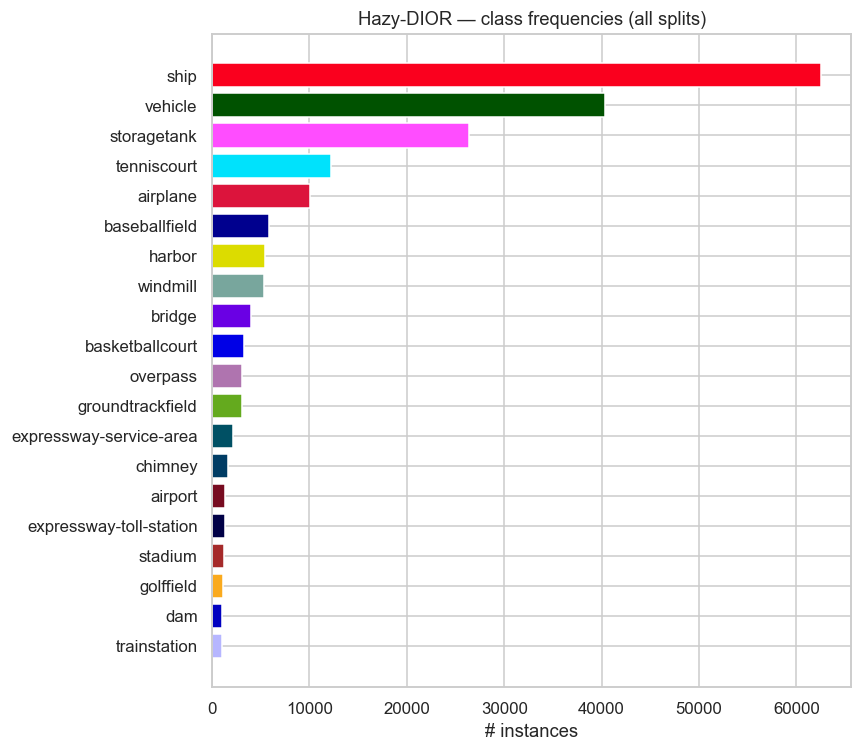

In [57]:
# Horizontal bar chart, sorted by total frequency, DIOR palette
if not df_boxes.empty:
    order = freq.index.tolist()
    colors = [PALETTE_NORM[CLS2IDX[c]] for c in order]
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(order[::-1], freq["count"].values[::-1], color=colors[::-1])
    ax.set_xlabel("# instances")
    ax.set_title("Hazy-DIOR — class frequencies (all splits)")
    plt.tight_layout(); plt.show()


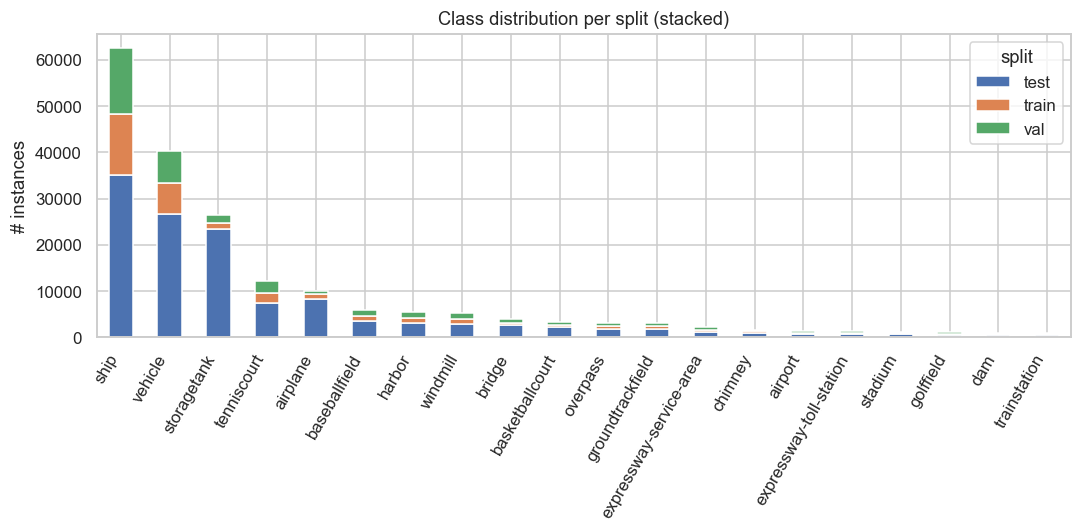

In [58]:
# Stacked bar — class distribution per split
if not df_boxes.empty:
    pivot = (df_boxes.groupby(["class", "split"]).size()
             .unstack(fill_value=0)
             .reindex(order))
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax,
               color=["#4C72B0", "#DD8452", "#55A868", "#999999"][:pivot.shape[1]])
    ax.set_title("Class distribution per split (stacked)")
    ax.set_ylabel("# instances"); ax.set_xlabel("")
    plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()


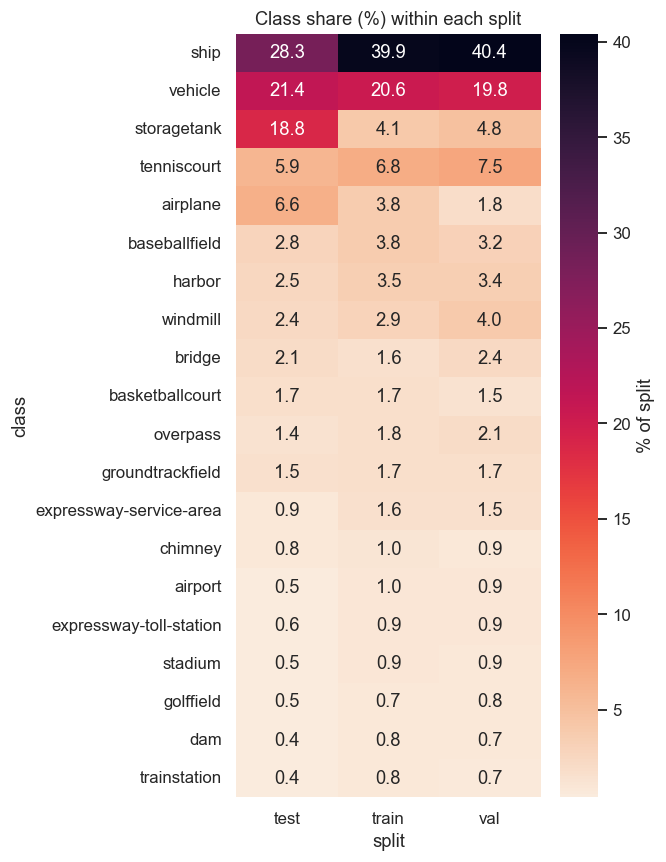

In [59]:
# Class x split heatmap (% within split)
if not df_boxes.empty:
    pct_per_split = pivot.div(pivot.sum(axis=0), axis=1) * 100
    fig, ax = plt.subplots(figsize=(6, 8))
    sns.heatmap(pct_per_split, annot=True, fmt=".1f", cmap="rocket_r",
                cbar_kws={"label": "% of split"}, ax=ax)
    ax.set_title("Class share (%) within each split"); plt.tight_layout(); plt.show()


## 7 — Bounding-box statistics

Size, aspect-ratio, rotation angle, count-per-image and spatial distribution.

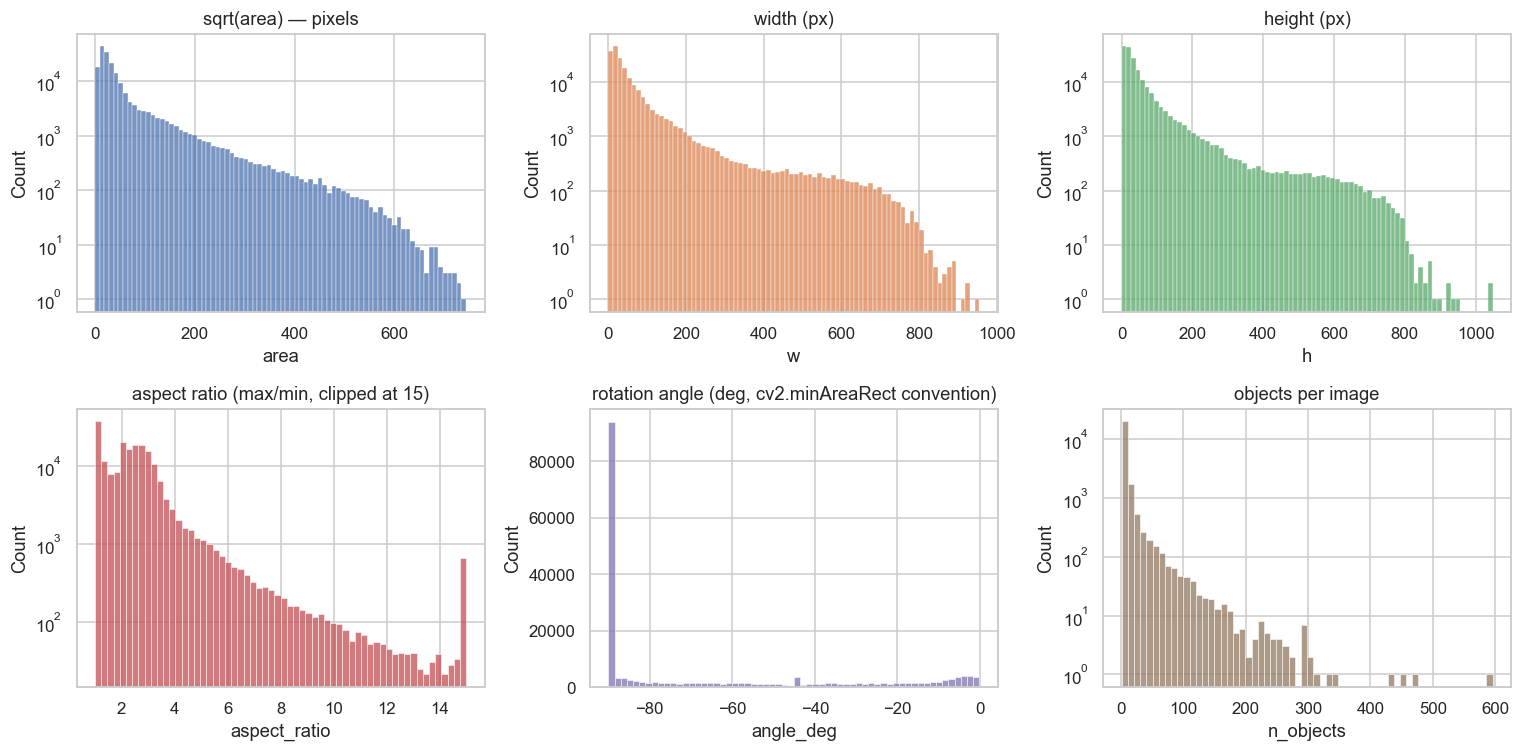

In [60]:
if not df_boxes.empty:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()

    sns.histplot(np.sqrt(df_boxes["area"]), bins=80, ax=axes[0], color="#4C72B0")
    axes[0].set_title("sqrt(area) — pixels"); axes[0].set_yscale("log")

    sns.histplot(df_boxes["w"], bins=80, ax=axes[1], color="#DD8452")
    axes[1].set_title("width (px)"); axes[1].set_yscale("log")

    sns.histplot(df_boxes["h"], bins=80, ax=axes[2], color="#55A868")
    axes[2].set_title("height (px)"); axes[2].set_yscale("log")

    sns.histplot(np.clip(df_boxes["aspect_ratio"], 1, 15), bins=60, ax=axes[3], color="#C44E52")
    axes[3].set_title("aspect ratio (max/min, clipped at 15)"); axes[3].set_yscale("log")

    sns.histplot(df_boxes["angle_deg"], bins=60, ax=axes[4], color="#8172B2")
    axes[4].set_title("rotation angle (deg, cv2.minAreaRect convention)")

    sns.histplot(df_images["n_objects"], bins=60, ax=axes[5], color="#937860")
    axes[5].set_title("objects per image"); axes[5].set_yscale("log")

    plt.tight_layout(); plt.show()


C:\Users\Ridvan\AppData\Local\Temp\ipykernel_23636\3710825727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxes, x="class", y="sqrt_area", order=order,


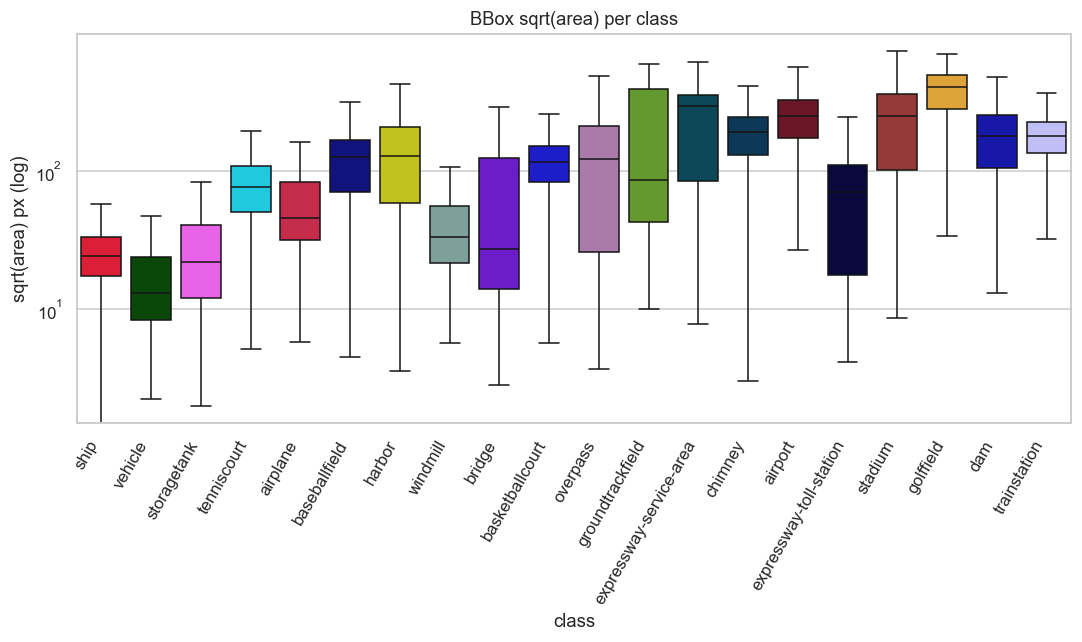

In [61]:
# Boxplot of sqrt(area) per class — surfaces ship-vs-airport scale gap
if not df_boxes.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_boxes["sqrt_area"] = np.sqrt(df_boxes["area"])
    sns.boxplot(data=df_boxes, x="class", y="sqrt_area", order=order,
                palette=[PALETTE_NORM[CLS2IDX[c]] for c in order], ax=ax,
                showfliers=False)
    ax.set_yscale("log"); ax.set_ylabel("sqrt(area) px (log)")
    ax.set_title("BBox sqrt(area) per class")
    plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()


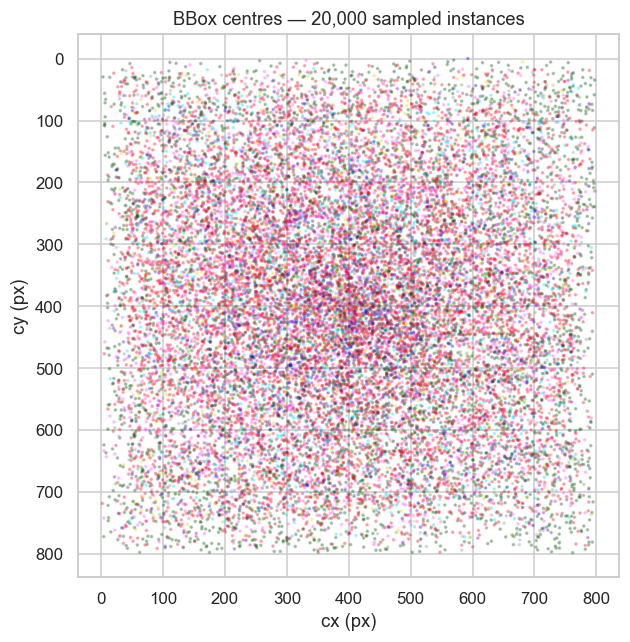

In [62]:
# Spatial bias — bbox centers across the image canvas
if not df_boxes.empty:
    sample = df_boxes.sample(min(20_000, len(df_boxes)), random_state=0)
    fig, ax = plt.subplots(figsize=(6, 6))
    cls_idx = sample["class"].map(CLS2IDX).values
    ax.scatter(sample["cx"], sample["cy"], s=2, alpha=0.25,
               c=[PALETTE_NORM[i] for i in cls_idx])
    ax.invert_yaxis(); ax.set_aspect("equal")
    ax.set_title(f"BBox centres — {len(sample):,} sampled instances")
    ax.set_xlabel("cx (px)"); ax.set_ylabel("cy (px)")
    plt.tight_layout(); plt.show()


In [63]:
# Objects-per-image summary
if not df_images.empty:
    s = df_images["n_objects"]
    print(s.describe(percentiles=[0.5, 0.75, 0.95, 0.99]).to_string())
    print(f"\nEmpty-image rate: {(s == 0).mean():.2%}  ({(s == 0).sum():,} images)")


count    23463.000000
mean         8.205174
std         20.606974
min          1.000000
50%          3.000000
75%          7.000000
95%         30.000000
99%        103.380000
max        596.000000

Empty-image rate: 0.00%  (0 images)


## 8 — Image statistics

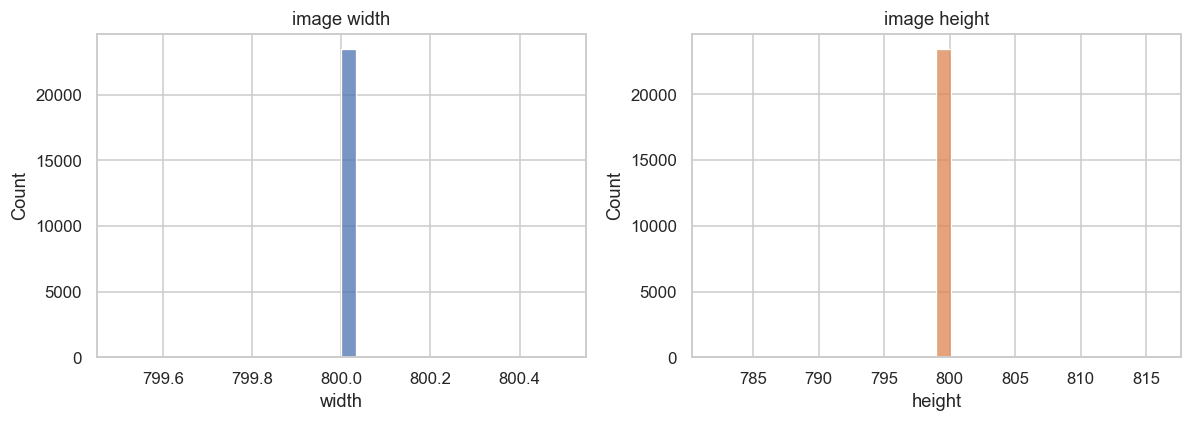


Top 10 most common (width, height):
width  height
800    800       23430
       801           7
       788           7
       787           6
       813           3
       783           2
       816           2
       784           1
       782           1
       797           1


In [64]:
if not df_images.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(df_images["width"].dropna(), bins=30, ax=axes[0], color="#4C72B0")
    axes[0].set_title("image width")
    sns.histplot(df_images["height"].dropna(), bins=30, ax=axes[1], color="#DD8452")
    axes[1].set_title("image height")
    plt.tight_layout(); plt.show()

    by_size = (df_images.groupby(["width", "height"]).size()
               .sort_values(ascending=False).head(10).rename("count"))
    print("\nTop 10 most common (width, height):")
    print(by_size.to_string())


## 9 — Sample visualisations with oriented bounding boxes

Random sample grid per split, plus a small "stress test" grid (most objects / largest box / smallest box) to sanity-check the parser.

In [ ]:
# --- Section-9 bootstrap -------------------------------------------------
# Ensures ALIGNED_PATHS / ALIGNED_GT / HAS_ALIGNED exist even if cell 11
# was the old version. Stems in test/* are canonical DIOR IDs; stems in
# train/* and val/* are local sequential indices and must NOT be overlaid.
try:
    ALIGNED_PATHS  # type: ignore[name-defined]
except NameError:
    ALIGNED_PATHS = {}
    ALIGNED_GT    = {}
    _exts = {".png", ".jpg", ".jpeg"}
    test_root = DATA_ROOT / "test"
    if test_root.exists():
        for branch, store in (("haze", ALIGNED_PATHS), ("gt", ALIGNED_GT)):
            d = test_root / branch
            if d.exists():
                for p in d.rglob("*"):
                    if p.is_file() and p.suffix.lower() in _exts:
                        store.setdefault(p.stem, p)
    print(f"[bootstrap] ALIGNED_PATHS built from {test_root}: "
          f"{len(ALIGNED_PATHS):,} hazy / {len(ALIGNED_GT):,} clean")

HAS_ALIGNED = len(ALIGNED_PATHS) > 0

# Backfill img_aligned on df_images if cell 18 was the old version
if "df_images" in dir() and not df_images.empty and "img_aligned" not in df_images.columns:
    df_images["img_aligned"] = df_images["image_id"].isin(ALIGNED_PATHS)
    print(f"[bootstrap] added img_aligned column "
          f"({int(df_images['img_aligned'].sum()):,} aligned rows)")


def draw_obb(img, polygons, labels, thickness=2, font_scale=0.45):
    out = img.copy()
    for poly, lab in zip(polygons, labels):
        pts = np.asarray(poly, dtype=np.int32).reshape(-1, 1, 2)
        col_rgb = PALETTE[CLS2IDX.get(lab, 0)]
        col_bgr = (int(col_rgb[2]), int(col_rgb[1]), int(col_rgb[0]))
        cv2.polylines(out, [pts], isClosed=True, color=col_bgr, thickness=thickness)
        x, y = int(pts[0, 0, 0]), int(pts[0, 0, 1])
        cv2.putText(out, lab, (x, max(y - 4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, col_bgr, 1, cv2.LINE_AA)
    return out


def load_image_with_boxes(image_id):
    """Load a hazy image and its OBBs - only for DIOR-ID-aligned images."""
    img_path = ALIGNED_PATHS.get(image_id)
    if img_path is None or not img_path.exists():
        return None
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        return None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rows = df_boxes[df_boxes["image_id"] == image_id]
    polys  = [json.loads(p) for p in rows["polygon"].tolist()]
    labels = rows["class"].tolist()
    return rgb, polys, labels


def grid(image_ids, cols=4, title=""):
    image_ids = [i for i in image_ids if i in ALIGNED_PATHS]
    if not image_ids:
        print(f"[SKIP] {title}: no DIOR-ID-aligned images for these IDs.")
        return
    rows = (len(image_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_2d(axes).flatten()
    for ax in axes:
        ax.axis("off")
    for ax, iid in zip(axes, image_ids):
        loaded = load_image_with_boxes(iid)
        if loaded is None:
            continue
        rgb, polys, labels = loaded
        ax.imshow(draw_obb(rgb, polys, labels))
        sev = ALIGNED_PATHS[iid].parent.name   # severity tier the picked file came from
        ax.set_title(f"{iid}  [{sev}]", fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()


In [67]:
# Random samples per split (restricted to DIOR-ID-aligned images in test/*)
rng = np.random.default_rng(seed=42)
if not df_images.empty and HAS_ALIGNED:
    for split in ["train", "val", "test"]:
        ids = df_images.query("split == @split and n_objects > 0 and img_aligned")["image_id"].tolist()
        if not ids:
            print(f"[SKIP] split={split}: no aligned images (the test/ subtree only "
                  f"covers a subset of DIOR IDs across all three splits).")
            continue
        picks = rng.choice(ids, size=min(12, len(ids)), replace=False).tolist()
        grid(picks, cols=4, title=f"{split}: 12 random samples with OBB overlays (DIOR-ID-aligned)")
elif not HAS_ALIGNED:
    print("[SKIP] no DIOR-ID-aligned images found - section 9 cannot overlay XML boxes safely.")


NameError: name 'HAS_ALIGNED' is not defined

In [ ]:
# Stress test: most objects / largest box / smallest box (DIOR-ID-aligned only)
if not df_images.empty and not df_boxes.empty and HAS_ALIGNED:
    aligned_ids = set(df_images.query("img_aligned")["image_id"])
    df_imgs_a = df_images[df_images["image_id"].isin(aligned_ids)]
    df_boxs_a = df_boxes[df_boxes["image_id"].isin(aligned_ids)]
    by_count = df_imgs_a.sort_values("n_objects", ascending=False).head(4)["image_id"].tolist()
    by_max   = (df_boxs_a.groupby("image_id")["area"].max()
                .sort_values(ascending=False).head(4).index.tolist())
    by_min   = (df_boxs_a[df_boxs_a["area"] > 0].groupby("image_id")["area"].min()
                .sort_values(ascending=True).head(4).index.tolist())
    grid(by_count, cols=4, title="Most objects in image (aligned)")
    grid(by_max,   cols=4, title="Largest single bbox area (aligned)")
    grid(by_min,   cols=4, title="Smallest single bbox area (aligned)")


## 10 — Haze-specific characteristics

The reason this dataset exists: every image carries synthetic haze of varying severity. We quantify haze with four lenses.

In [ ]:
# Shared random subset of N images for the haze sections.
# We sample from HAZE_PATHS (one canonical Path per image_id) rather than from
# raw file lists — keeps the sample diverse across train/val/test.
HAZE_SAMPLE_N = 500

if HAS_IMAGES:
    all_imgs = list(HAZE_PATHS.values())
    rng2 = np.random.default_rng(seed=7)
    haze_sample_paths = rng2.choice(all_imgs, size=min(HAZE_SAMPLE_N, len(all_imgs)), replace=False).tolist()
    print(f"Haze sample: {len(haze_sample_paths)} images")
else:
    haze_sample_paths = []


### 10.1 Per-channel intensity stats

In [ ]:
def load_rgb_resized(path: Path, max_side: int = 512) -> np.ndarray | None:
    bgr = cv2.imread(str(path))
    if bgr is None:
        return None
    h, w = bgr.shape[:2]
    s = max_side / max(h, w)
    if s < 1:
        bgr = cv2.resize(bgr, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


channel_rows = []
hist_accum = np.zeros((3, 256), dtype=np.float64)
for p in tqdm(haze_sample_paths, desc="10.1 channel stats"):
    img = load_rgb_resized(Path(p))
    if img is None:
        continue
    flat = img.reshape(-1, 3)
    channel_rows.append({
        "file": Path(p).name,
        "R_mean": flat[:, 0].mean(), "G_mean": flat[:, 1].mean(), "B_mean": flat[:, 2].mean(),
        "R_std":  flat[:, 0].std(),  "G_std":  flat[:, 1].std(),  "B_std":  flat[:, 2].std(),
    })
    for c in range(3):
        h, _ = np.histogram(img[..., c], bins=256, range=(0, 256))
        hist_accum[c] += h
df_chan = pd.DataFrame(channel_rows)

if not df_chan.empty:
    print(df_chan[["R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std"]]
          .describe().round(2).to_string())


In [ ]:
if not df_chan.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for c, name, col in zip(range(3), ["R", "G", "B"], ["#d62728", "#2ca02c", "#1f77b4"]):
        axes[0].plot(hist_accum[c] / hist_accum[c].sum(), color=col, label=name)
    axes[0].set_title("Per-channel intensity (normalised, summed over sample)")
    axes[0].set_xlabel("intensity 0-255"); axes[0].legend()

    melted = df_chan.melt(value_vars=["R_mean", "G_mean", "B_mean"],
                          var_name="channel", value_name="mean")
    sns.violinplot(data=melted, x="channel", y="mean",
                   palette=["#d62728", "#2ca02c", "#1f77b4"], ax=axes[1])
    axes[1].set_title("Per-image channel means (sample)")
    plt.tight_layout(); plt.show()


### 10.2 — Dark Channel Prior  &  10.3 — Atmospheric light

He et al., 2009. For each pixel: `DC(x) = min_{y in patch} min_c I_c(y)`. Hazy images have characteristically high dark-channel values. The atmospheric light is estimated as the median RGB of the brightest 0.1% of dark-channel pixels.

In [ ]:
def dark_channel(img: np.ndarray, patch: int = 15) -> np.ndarray:
    """img: HxWx3 uint8 RGB. Returns HxW uint8."""
    min_c = img.min(axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
    return cv2.erode(min_c, kernel)


def atmospheric_light(img: np.ndarray, dc: np.ndarray, top_frac: float = 0.001) -> np.ndarray:
    flat_dc  = dc.reshape(-1)
    flat_img = img.reshape(-1, 3)
    k = max(1, int(top_frac * flat_dc.size))
    idx = np.argpartition(flat_dc, -k)[-k:]
    return np.median(flat_img[idx], axis=0)


dcp_rows = []
for p in tqdm(haze_sample_paths, desc="10.2/10.3 dark channel"):
    img = load_rgb_resized(Path(p))
    if img is None:
        continue
    dc = dark_channel(img, patch=15)
    A = atmospheric_light(img, dc)
    dcp_rows.append({
        "file": Path(p).name,
        "dcp_mean":   float(dc.mean()),
        "dcp_median": float(np.median(dc)),
        "dcp_p95":    float(np.percentile(dc, 95)),
        "A_R": float(A[0]), "A_G": float(A[1]), "A_B": float(A[2]),
        "A_mean": float(A.mean()),
    })
df_dcp = pd.DataFrame(dcp_rows)
print(df_dcp[["dcp_mean", "dcp_median", "dcp_p95", "A_mean"]].describe().round(2).to_string())


In [ ]:
if not df_dcp.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_dcp["dcp_mean"], bins=40, ax=axes[0], color="#444444")
    axes[0].axvline(40, color="red", linestyle="--",
                    label="loose 'hazy' threshold ≈ 40")
    axes[0].set_title("Dark Channel Prior — per-image mean")
    axes[0].set_xlabel("mean DC value (0-255)"); axes[0].legend()

    sns.histplot(df_dcp["A_mean"], bins=40, ax=axes[1], color="#999900")
    axes[1].set_title("Atmospheric light intensity (mean of A)")
    axes[1].set_xlabel("0-255")
    plt.tight_layout(); plt.show()


### 10.4 — Colorfulness  &  RMS contrast

* **Hasler-Süsstrunk colorfulness** (2003): combines opposite-color axes `rg = R - G` and `yb = 0.5·(R + G) - B`.
* **RMS contrast**: standard deviation of pixel intensities in the luminance channel.

Hazy images typically score lower on both.

In [ ]:
def hasler_susstrunk_colorfulness(img: np.ndarray) -> float:
    R, G, B = img[..., 0].astype(np.float32), img[..., 1].astype(np.float32), img[..., 2].astype(np.float32)
    rg = R - G
    yb = 0.5 * (R + G) - B
    std_rgyb  = np.sqrt(rg.std()**2  + yb.std()**2)
    mean_rgyb = np.sqrt(rg.mean()**2 + yb.mean()**2)
    return float(std_rgyb + 0.3 * mean_rgyb)


def rms_contrast(img: np.ndarray) -> float:
    Y = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return float(Y.std())


col_rows = []
for p in tqdm(haze_sample_paths, desc="10.4 colorfulness/contrast"):
    img = load_rgb_resized(Path(p))
    if img is None:
        continue
    col_rows.append({
        "file": Path(p).name,
        "colorfulness": hasler_susstrunk_colorfulness(img),
        "rms_contrast": rms_contrast(img),
    })
df_col = pd.DataFrame(col_rows)
print(df_col.describe().round(2).to_string())


In [ ]:
if not df_col.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_col["colorfulness"], bins=40, ax=axes[0], color="#1f77b4")
    axes[0].set_title("Hasler-Süsstrunk colorfulness")
    sns.histplot(df_col["rms_contrast"], bins=40, ax=axes[1], color="#d62728")
    axes[1].set_title("RMS contrast (luminance std)")
    plt.tight_layout(); plt.show()


### 10.5 — Clean DIOR vs Hazy DIOR (side-by-side)

The Hazy-DIOR release ships paired clean images under each split's `gt/` folder, sitting next to `haze/`. When present, we use those directly (matched by file stem). As a fallback, we also hunt for a separate clean-DIOR copy (a `DIOR/JPEGImages/` tree).

In [ ]:
# Prefer the local gt/ siblings shipped alongside haze/ in the split layout.
# Fall back to hunting for a separate clean-DIOR copy.
if CLEAN_PATHS:
    CLEAN_IMG_DIR = "split-gt"   # sentinel — lookups go through CLEAN_PATHS map
    print(f"[OK] Using local gt/ folders as clean source ({len(CLEAN_PATHS):,} unique IDs)")
else:
    clean_candidates = [
        ARCHIVE_DIR / "DIOR",
        ARCHIVE_DIR / "DIOR" / "JPEGImages",
        ARCHIVE_DIR.parent / "DIOR",
        ARCHIVE_DIR.parent / "DIOR" / "JPEGImages",
    ]
    CLEAN_IMG_DIR = next(
        (c if c.name == "JPEGImages" else c / "JPEGImages"
         for c in clean_candidates
         if (c if c.name == "JPEGImages" else c / "JPEGImages").exists()),
        None,
    )
    if CLEAN_IMG_DIR is None:
        print(
            "[INFO] No clean source detected. To enable this section, either:\n"
            "  - keep the gt/ siblings inside the split layout, or\n"
            "  - place clean DIOR at one of:\n"
            + "\n".join(f"      {c}" for c in clean_candidates)
        )
    else:
        print(f"[OK] Clean DIOR found at: {CLEAN_IMG_DIR}")


In [ ]:
def _clean_for(hp: Path) -> Path | None:
    """Resolve the clean counterpart of a hazy path. Stem-based match."""
    if CLEAN_PATHS:
        return CLEAN_PATHS.get(Path(hp).stem)
    if isinstance(CLEAN_IMG_DIR, Path):
        cand = CLEAN_IMG_DIR / Path(hp).name
        return cand if cand.exists() else None
    return None

if (CLEAN_PATHS or isinstance(CLEAN_IMG_DIR, Path)) and haze_sample_paths:
    pair_paths = [(hp, _clean_for(hp)) for hp in haze_sample_paths]
    pair_paths = [(hp, cp) for hp, cp in pair_paths if cp is not None][:200]
    print(f"Pairing {len(pair_paths)} images")

    rows = []
    for hp, cp in tqdm(pair_paths, desc="10.5 paired metrics"):
        hi, ci = load_rgb_resized(Path(hp)), load_rgb_resized(cp)
        if hi is None or ci is None:
            continue
        rows.append({
            "file": Path(hp).name,
            "hazy_dcp":  float(dark_channel(hi).mean()),
            "clean_dcp": float(dark_channel(ci).mean()),
            "hazy_color":  hasler_susstrunk_colorfulness(hi),
            "clean_color": hasler_susstrunk_colorfulness(ci),
            "hazy_rms":    rms_contrast(hi),
            "clean_rms":   rms_contrast(ci),
        })
    df_pair = pd.DataFrame(rows)

    if not df_pair.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, m in zip(axes, ["dcp", "color", "rms"]):
            sns.histplot(df_pair[f"clean_{m}"], bins=30, ax=ax, color="#1f77b4",
                         label="clean", stat="density", alpha=0.55)
            sns.histplot(df_pair[f"hazy_{m}"],  bins=30, ax=ax, color="#d62728",
                         label="hazy",  stat="density", alpha=0.55)
            ax.set_title({"dcp": "Dark Channel Prior (mean)",
                          "color": "Colorfulness",
                          "rms": "RMS contrast"}[m])
            ax.legend()
        plt.tight_layout(); plt.show()

        # 4 side-by-side examples
        n = min(4, len(pair_paths))
        fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
        if n == 1:
            axes = axes[None, :]
        for i, (hp, cp) in enumerate(pair_paths[:n]):
            axes[i, 0].imshow(load_rgb_resized(cp));   axes[i, 0].set_title(f"clean — {Path(hp).name}")
            axes[i, 1].imshow(load_rgb_resized(Path(hp))); axes[i, 1].set_title("hazy")
            for a in axes[i]:
                a.axis("off")
        plt.tight_layout(); plt.show()
else:
    print("[SKIP] no clean source available.")


## 11 — Save outputs

CSVs of every table and a one-shot text summary, all under `eda_outputs/`.

In [ ]:
def save_csv(df: pd.DataFrame, name: str) -> None:
    if not df.empty:
        path = OUT_DIR / f"{name}.csv"
        df.to_csv(path, index=False)
        print(f"  wrote {path.name}  ({len(df):,} rows)")

if not df_images.empty: save_csv(df_images, "df_images")
if not df_boxes.empty:  save_csv(df_boxes.drop(columns=["polygon"], errors="ignore"), "df_boxes")
try:
    save_csv(df_chan, "haze_channel_stats")
    save_csv(df_dcp,  "haze_dark_channel_prior")
    save_csv(df_col,  "haze_colorfulness_contrast")
except NameError:
    pass
print("done.")


In [ ]:
# Auto-generated summary
lines = ["# Hazy-DIOR — EDA summary\n"]

if not df_images.empty:
    lines.append(f"* total images parsed: **{len(df_images):,}**")
    lines.append(f"* total objects: **{len(df_boxes):,}**")
    lines.append(f"* classes: **{df_boxes['class'].nunique()}** / {len(CLASSES)} expected")
    lines.append(f"* mean objects per image: **{df_images['n_objects'].mean():.1f}** "
                 f"(median {df_images['n_objects'].median():.0f}, "
                 f"max {df_images['n_objects'].max()})")
    lines.append(f"* empty-image rate: **{(df_images['n_objects'] == 0).mean():.1%}**")

if splits:
    for k, v in splits.items():
        if k == "trainval":
            continue
        lines.append(f"* split `{k}`: **{len(v):,}** images")

if 'df_dcp' in dir() and not df_dcp.empty:
    lines.append(f"* dark-channel mean (sample n={len(df_dcp)}): "
                 f"**{df_dcp['dcp_mean'].mean():.1f}** ± {df_dcp['dcp_mean'].std():.1f}")
    lines.append(f"* atmospheric light mean: **{df_dcp['A_mean'].mean():.1f}**")

if 'df_col' in dir() and not df_col.empty:
    lines.append(f"* mean colorfulness: **{df_col['colorfulness'].mean():.1f}**")
    lines.append(f"* mean RMS contrast: **{df_col['rms_contrast'].mean():.1f}**")

summary = "\n".join(lines)
(OUT_DIR / "summary.md").write_text(summary, encoding="utf-8")
print(summary)
